# Решение ДЗ: 6 архитектур нейросетей для задачи регрессии (HeadHunter)

**Задание:** На основе подготовленной таблицы данных HeadHunter создать **6 архитектур** нейросетей, поэкспериментировать с гиперпараметрами. Использовать **только числовые данные** (вектор `x_train_01` размерности 39), текстовые не подавать. В конце — анализ результатов.

**План работы:**
1. Импорт и подготовка данных (повтор раздела «Подготовка»).
2. Нормализация целевой переменной `y_train` (`StandardScaler`).
3. Разделение на обучающую и проверочную выборки.
4. Шесть архитектур, отличающихся:
   - количеством и шириной слоёв,
   - функциями активации,
   - наличием `BatchNormalization` / `Dropout`,
   - оптимизатором и `learning_rate`,
   - размером батча и числом эпох.
5. Сводная таблица и графики, итоговый вывод.


## 1. Импорты

In [ ]:
# Работа с массивами и таблицами
import numpy as np
import pandas as pd

# Keras
from tensorflow.keras import utils
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                     Input, concatenate, Activation)
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad
from tensorflow.keras.callbacks import LambdaCallback

# Прочее
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import gdown
import re
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)


## 2. Подготовка данных
Полностью повторяем код раздела «Подготовка» из базового ноутбука: скачиваем CSV, очищаем строки, парсим столбцы и собираем числовой вектор признаков длиной 39.

In [ ]:
# Скачиваем базу
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l10/hh_fixed.csv',
               None, quiet=True)

# Чтение
df = pd.read_csv('hh_fixed.csv', index_col=0)
print('Размер исходного датафрейма:', df.shape)
df.head(3)


Размер исходного датафрейма: (62967, 12)


,"Пол, возраст",ЗП,Ищет работу на должность:,Город,Занятость,График,Опыт (двойное нажатие для полной версии),Последенее/нынешнее место работы,Последеняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 29 лет , родился 16 мая 1989",40000 руб.,Специалист по поддержке чата(support team) дом...,"Новороссийск , готов к переезду (Анапа, Геленд...",полная занятость,полный день,Опыт работы 3 года 9 месяцев Специалист по по...,"ООО ""Гольфстрим""",Генеральный директор,Высшее образование 2011 Международный юридиче...,26.04.2019 08:04,Не указано
1,"Мужчина , 38 лет , родился 25 мая 1980",40000 руб.,Системный администратор,"Новосибирск , м. Березовая роща , не готов к ...",полная занятость,полный день,Опыт работы 11 лет 11 месяцев Системный админ...,ООО «Завод модульных технологий»,Системный администратор,Высшее образование 2002 Новосибирский государс...,26.04.2019 04:30,Не указано
2,"Мужчина , 35 лет , родился 14 июня 1983",300000 руб.,DevOps TeamLead / DevOps архитектор,"Москва , готов к переезду , готов к редким ком...",полная занятость,полный день,Опыт работы 12 лет 11 месяцев DevOps TeamLead...,Банк ВТБ (ПАО),Начальник отдела методологии разработки (DevOp...,DevOps TeamLead / DevOps архитектор 300 000 ру...,09.04.2019 14:40,Не указано


In [ ]:
# Номера столбцов
COL_SEX_AGE  = df.columns.get_loc('Пол, возраст')
COL_SALARY   = df.columns.get_loc('ЗП')
COL_POS_SEEK = df.columns.get_loc('Ищет работу на должность:')
COL_POS_PREV = df.columns.get_loc('Последеняя/нынешняя должность')
COL_CITY     = df.columns.get_loc('Город')
COL_EMPL     = df.columns.get_loc('Занятость')
COL_SCHED    = df.columns.get_loc('График')
COL_EXP      = df.columns.get_loc('Опыт (двойное нажатие для полной версии)')
COL_EDU      = df.columns.get_loc('Образование и ВУЗ')
COL_UPDATED  = df.columns.get_loc('Обновление резюме')


In [ ]:
# Очистка строк
def purify(x):
    if isinstance(x, str):
        x = x.replace('\n', ' ').replace('\xa0', '').strip().lower()
    return x

# Применяем
for col in df.columns:
    df[col] = df[col].apply(purify)

# Извлечение года из даты
def extract_year(x):
    try:
        return int(re.search(r'\d\d.\d\d.(\d{4})', x)[1])
    except (IndexError, TypeError, ValueError):
        return 0


In [ ]:
# Параметрические данные
currency_rate = {'usd': 65., 'kzt': 0.17, 'грн': 2.6, 'белруб': 30.5,
                 'eur': 70., 'kgs': 0.9, 'сум': 0.007, 'azn': 37.5}

age_class        = [0, [18, 23, 28, 33, 38, 43, 48, 53, 58, 63]]
experience_class = [0, [7, 13, 25, 37, 61, 97, 121, 157, 193, 241]]

city_class = [0,
              {'москва': 0, 'санкт-петербург': 1,
               'новосибирск': 2, 'екатеринбург': 2, 'нижний новгород': 2,
               'казань': 2, 'челябинск': 2, 'омск': 2, 'самара': 2,
               'ростов-на-дону': 2, 'уфа': 2, 'красноярск': 2, 'пермь': 2,
               'воронеж': 2, 'волгоград': 2,
               'прочие города': 3}]

employment_class = [0, {'стажировка': 0, 'частичная занятость': 1,
                        'проектная работа': 2, 'полная занятость': 3}]

schedule_class   = [0, {'гибкий график': 0, 'полный день': 1,
                        'сменный график': 2, 'удаленная работа': 3}]

education_class  = [0, {'высшее образование': 0, 'higher education': 0,
                        'среднее специальное': 1, 'неоконченное высшее': 2,
                        'среднее образование': 3}]

# Подсчёт количества классов
for class_lst in [age_class, experience_class]:
    class_lst[0] = len(class_lst[1]) + 1
for class_dct in [city_class, employment_class, schedule_class, education_class]:
    class_dct[0] = max(class_dct[1].values()) + 1

print('Возраст -', age_class[0], 'классов')
print('Опыт -', experience_class[0], 'классов')
print('Города -', city_class[0], 'классов')


Возраст - 11 классов
Опыт - 11 классов
Города - 4 классов


In [ ]:
# One-hot для целочисленного значения
def int_to_ohe(arg, class_list):
    num_classes = class_list[0]
    for i in range(num_classes - 1):
        if arg < class_list[1][i]:
            cls = i
            break
    else:
        cls = num_classes - 1
    return utils.to_categorical(cls, num_classes)

# Multi-hot из строки и словаря
def str_to_multi(arg, class_dict):
    num_classes = class_dict[0]
    result = np.zeros(num_classes)
    for value, cls in class_dict[1].items():
        if value in arg:
            result[cls] = 1.
    return result


In [ ]:
# Парсинг пола и возраста
base_update_year = 2019

def extract_sex_age_years(arg):
    sex = 1. if 'муж' in arg else 0.
    try:
        years = base_update_year - int(re.search(r'\d{4}', arg)[0])
    except (IndexError, TypeError, ValueError):
        years = 0
    return sex, years

def age_years_to_ohe(arg):
    return int_to_ohe(arg, age_class)

def experience_months_to_ohe(arg):
    return int_to_ohe(arg, experience_class)

# Парсинг зарплаты
def extract_salary(arg):
    try:
        value = float(re.search(r'\d+', arg)[0])
        for currency, rate in currency_rate.items():
            if currency in arg:
                value *= rate
                break
    except TypeError:
        value = 0.
    return value / 1000.   # тыс. рублей


In [ ]:
# Город -> one-hot
def extract_city_to_ohe(arg):
    num_classes = city_class[0]
    split_array = re.split(r'[ ,.:()?!]', arg)
    for word in split_array:
        city_cls = city_class[1].get(word, -1)
        if city_cls >= 0:
            break
    else:
        city_cls = num_classes - 1
    return utils.to_categorical(city_cls, num_classes)

# Multi-hot для занятости / графика / образования
def extract_employment_to_multi(arg):
    return str_to_multi(arg, employment_class)

def extract_schedule_to_multi(arg):
    return str_to_multi(arg, schedule_class)

def extract_education_to_multi(arg):
    result = str_to_multi(arg, education_class)
    if result[2] > 0.:           # неоконченное высшее ⇒ убираем «высшее»
        result[0] = 0.
    return result

# Опыт работы (месяцев)
def extract_experience_months(arg):
    try:
        years = int(re.search(r'(\d+)\s+(год.?|лет)', arg)[1])
    except (IndexError, TypeError, ValueError):
        years = 0
    try:
        months = int(re.search(r'(\d+)\s+месяц', arg)[1])
    except (IndexError, TypeError, ValueError):
        months = 0
    return years * 12 + months


In [ ]:
# Сборка одной строки
def extract_row_data(row):
    sex, age = extract_sex_age_years(row[COL_SEX_AGE])
    sex_vec   = np.array([sex])
    age_ohe   = age_years_to_ohe(age)
    city_ohe  = extract_city_to_ohe(row[COL_CITY])
    empl_mult = extract_employment_to_multi(row[COL_EMPL])
    sched_mlt = extract_schedule_to_multi(row[COL_SCHED])
    edu_multi = extract_education_to_multi(row[COL_EDU])
    exp_mon   = extract_experience_months(row[COL_EXP])
    exp_ohe   = experience_months_to_ohe(exp_mon)
    salary    = extract_salary(row[COL_SALARY])
    salary_v  = np.array([salary])

    x_data = np.hstack([sex_vec, age_ohe, city_ohe,
                        empl_mult, sched_mlt, edu_multi, exp_ohe])
    return x_data, salary_v

# Сбор всей выборки
def construct_train_data(row_list):
    x_data, y_data = [], []
    for row in row_list:
        x, y = extract_row_data(row)
        if y[0] > 0:
            x_data.append(x)
            y_data.append(y)
    return np.array(x_data), np.array(y_data)


In [ ]:
# Формируем выборку
x_train_01, y_train = construct_train_data(df.values)
print('x_train_01.shape =', x_train_01.shape)
print('y_train.shape    =', y_train.shape)
print('Пример x:', x_train_01[0])
print('Пример y:', y_train[0])


x_train_01.shape = (62967, 39)
y_train.shape    = (62967, 1)
Пример x: [1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
Пример y: [40.]


## 3. Нормализация целевой переменной и валидационная выборка
По теории зарплату нормируем (StandardScaler) — это сильно ускоряет сходимость регрессии. После каждого обучения денормируем предсказание и считаем ошибку в **тысячах рублей**.

In [ ]:
# Нормализация y
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)

print('mean ≈', round(y_train_scaled.mean(), 4),
      ', std ≈', round(y_train_scaled.std(), 4))


mean ≈ -0.0 , std ≈ 1.0


In [ ]:
# Маска для валидации (~15%)
np.random.seed(42)
val_mask = np.random.rand(len(x_train_01)) < 0.15
print('Train:', (~val_mask).sum(), '   Val:', val_mask.sum())

x_tr,  x_val  = x_train_01[~val_mask], x_train_01[val_mask]
y_tr,  y_val  = y_train_scaled[~val_mask], y_train_scaled[val_mask]
y_val_orig    = y_train[val_mask]  # для финальной денормированной MAE


Train: 53543    Val: 9424


## 4. Вспомогательные функции
- `plot_history` — рисует MAE по эпохам (как в базовом блоке).
- `eval_net_scaled` — считает MAE в тыс. руб. на проверочной выборке (с обратной нормировкой).
- `MAE_RUB` — callback по [теории «Метрика через callbacks»](https://colab.research.google.com/drive/1FelcMWA_g8IbICzs4j3w3vf1JfuxymNR?usp=sharing): после каждой эпохи печатает MAE в реальных рублях и возвращает её историю для графиков.

In [ ]:
def plot_history(history, title=''):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['mae'],     label='MAE train')
    plt.plot(history.history['val_mae'], label='MAE val')
    plt.title(title)
    plt.xlabel('Эпоха обучения')
    plt.ylabel('MAE (нормированная)')
    plt.legend(); plt.grid(); plt.show()

def eval_net_scaled(model, x_val, y_val_orig):
    pred_scaled = model.predict(x_val, verbose=0)
    pred        = y_scaler.inverse_transform(pred_scaled)
    mae         = mean_absolute_error(y_val_orig, pred)
    return mae, pred


In [ ]:
# Callback по теории — выводит MAE в тыс. руб. в конце каждой эпохи
def make_rub_callback(model, x_val, y_val_orig, store):
    def on_epoch_end(epoch, logs):
        pred = y_scaler.inverse_transform(model.predict(x_val, verbose=0))
        mae  = float(np.mean(np.abs(pred - y_val_orig)))
        store.append(mae)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'  Эпоха {epoch+1:3d} | MAE val (тыс. руб.) = {mae:6.2f}')
    return LambdaCallback(on_epoch_end=on_epoch_end)


In [ ]:
# Здесь будут результаты всех 6 моделей
results = []  # [{name, params, mae, history, rub_history}]


## 5. Шесть архитектур

Кратко о подходе. Все 6 архитектур получают **один и тот же** числовой вход размерности 39 и предсказывают зарплату (`linear` на выходе, loss = MSE, метрика = MAE).
Различаются — глубина / ширина / активация / регуляризация / оптимизатор / batch_size / эпохи.

| № | Главная идея |
|---|---|
| 1 | Маленькая базовая сеть (2 слоя, ReLU, Adam) — старт, baseline |
| 2 | Глубокая сеть с BatchNormalization (4 слоя) |
| 3 | Очень широкая сеть (1 скрытый слой по 1024) |
| 4 | Сеть с Dropout — регуляризация против переобучения |
| 5 | Functional API + tanh + Adagrad — другой оптимизатор и активация |
| 6 | Глубокая «пирамидальная» сеть с BN + Dropout, RMSprop |

### Модель 1 — базовая (минимальная)
**Гиперпараметры:** 2 слоя по 64 / 32, активация `relu`, оптимизатор `Adam(lr=1e-3)`, `batch_size=128`, 30 эпох. Без регуляризации — точка отсчёта.

=== M1 baseline (Dense 64-32, Adam 1e-3) ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Эпоха   1 | MAE val (тыс. руб.) =  33.15
  Эпоха  10 | MAE val (тыс. руб.) =  31.80
  Эпоха  20 | MAE val (тыс. руб.) =  31.53
  Эпоха  30 | MAE val (тыс. руб.) =  31.62

Итоговый MAE (тыс. руб.): 31.62


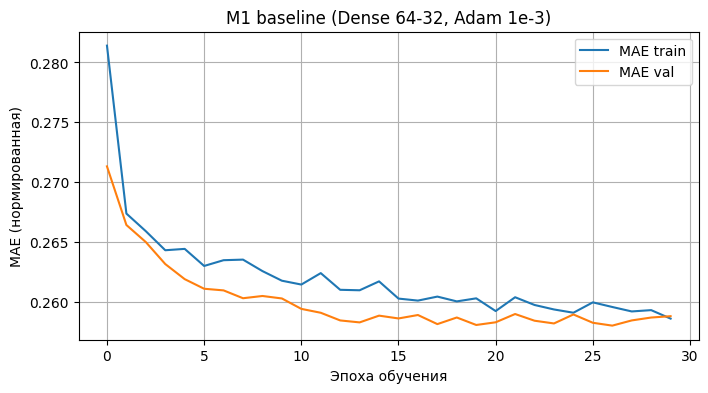

In [ ]:
name1 = 'M1 baseline (Dense 64-32, Adam 1e-3)'
print('=== ' + name1 + ' ===')

m1 = Sequential([
    Dense(64, activation='relu', input_dim=x_train_01.shape[1]),
    Dense(32, activation='relu'),
    Dense(1,  activation='linear'),
])
m1.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])

rub1 = []
h1 = m1.fit(x_tr, y_tr,
            validation_data=(x_val, y_val),
            epochs=30, batch_size=128, verbose=0,
            callbacks=[make_rub_callback(m1, x_val, y_val_orig, rub1)])

mae1, _ = eval_net_scaled(m1, x_val, y_val_orig)
print(f'\nИтоговый MAE (тыс. руб.): {mae1:.2f}')
plot_history(h1, name1)

results.append({'name': name1,
                'params': '2×Dense (64,32), Adam 1e-3, bs=128, ep=30',
                'mae': mae1, 'history': h1, 'rub_history': rub1})


### Модель 2 — глубокая с BatchNormalization
**Гиперпараметры:** 4 скрытых слоя (256→128→64→32), `BatchNormalization` после входа, активация `relu`, `Adam(lr=1e-3)`, `batch_size=256`, 50 эпох.
Идея: больше глубины + BN стабилизирует обучение.

=== M2 deep+BN (256-128-64-32, Adam 1e-3) ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Эпоха   1 | MAE val (тыс. руб.) =  33.73
  Эпоха  10 | MAE val (тыс. руб.) =  31.21
  Эпоха  20 | MAE val (тыс. руб.) =  31.72
  Эпоха  30 | MAE val (тыс. руб.) =  32.29
  Эпоха  40 | MAE val (тыс. руб.) =  32.44
  Эпоха  50 | MAE val (тыс. руб.) =  32.49

Итоговый MAE (тыс. руб.): 32.49


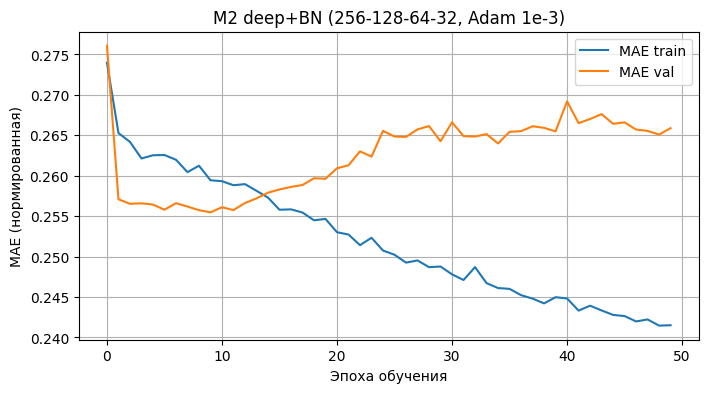

In [ ]:
name2 = 'M2 deep+BN (256-128-64-32, Adam 1e-3)'
print('=== ' + name2 + ' ===')

m2 = Sequential([
    BatchNormalization(input_dim=x_train_01.shape[1]),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(32,  activation='relu'),
    Dense(1,   activation='linear'),
])
m2.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])

rub2 = []
h2 = m2.fit(x_tr, y_tr,
            validation_data=(x_val, y_val),
            epochs=50, batch_size=256, verbose=0,
            callbacks=[make_rub_callback(m2, x_val, y_val_orig, rub2)])

mae2, _ = eval_net_scaled(m2, x_val, y_val_orig)
print(f'\nИтоговый MAE (тыс. руб.): {mae2:.2f}')
plot_history(h2, name2)

results.append({'name': name2,
                'params': 'BN + 4 Dense (256,128,64,32), Adam 1e-3, bs=256, ep=50',
                'mae': mae2, 'history': h2, 'rub_history': rub2})


### Модель 3 — широкая (1 большой скрытый слой)
**Гиперпараметры:** один скрытый слой `Dense(1024, relu)`, далее `Dense(64)`, `Adam(lr=5e-4)`, `batch_size=512`, 40 эпох.
Идея: проверить, помогает ли «ширина» при ограниченном входе (39 признаков).

=== M3 wide (1024-64, Adam 5e-4) ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Эпоха   1 | MAE val (тыс. руб.) =  31.40
  Эпоха  10 | MAE val (тыс. руб.) =  30.94
  Эпоха  20 | MAE val (тыс. руб.) =  30.94
  Эпоха  30 | MAE val (тыс. руб.) =  30.96
  Эпоха  40 | MAE val (тыс. руб.) =  31.03

Итоговый MAE (тыс. руб.): 31.03


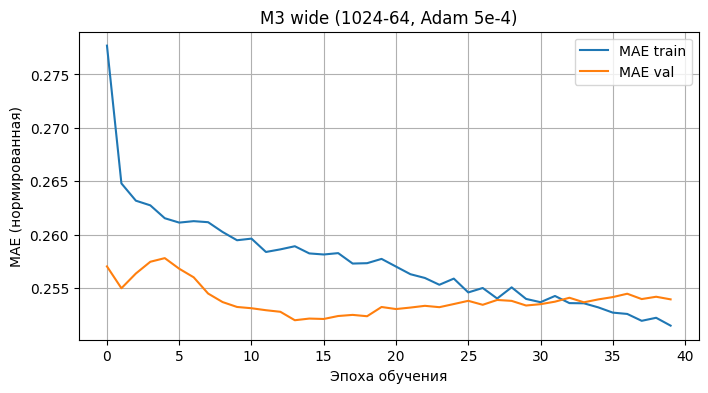

In [ ]:
name3 = 'M3 wide (1024-64, Adam 5e-4)'
print('=== ' + name3 + ' ===')

m3 = Sequential([
    Dense(1024, activation='relu', input_dim=x_train_01.shape[1]),
    Dense(64,   activation='relu'),
    Dense(1,    activation='linear'),
])
m3.compile(optimizer=Adam(learning_rate=5e-4), loss='mse', metrics=['mae'])

rub3 = []
h3 = m3.fit(x_tr, y_tr,
            validation_data=(x_val, y_val),
            epochs=40, batch_size=512, verbose=0,
            callbacks=[make_rub_callback(m3, x_val, y_val_orig, rub3)])

mae3, _ = eval_net_scaled(m3, x_val, y_val_orig)
print(f'\nИтоговый MAE (тыс. руб.): {mae3:.2f}')
plot_history(h3, name3)

results.append({'name': name3,
                'params': 'Dense 1024-64, Adam 5e-4, bs=512, ep=40',
                'mae': mae3, 'history': h3, 'rub_history': rub3})


### Модель 4 — Dropout-регуляризация
**Гиперпараметры:** 3 слоя (256→128→64) с `Dropout(0.3)` после каждого, `Adam(lr=1e-3)`, `batch_size=128`, 60 эпох.
Идея: Dropout должен препятствовать переобучению.

=== M4 dropout (256-128-64 + Dropout 0.3) ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Эпоха   1 | MAE val (тыс. руб.) =  34.32
  Эпоха  10 | MAE val (тыс. руб.) =  32.37
  Эпоха  20 | MAE val (тыс. руб.) =  32.48
  Эпоха  30 | MAE val (тыс. руб.) =  32.47
  Эпоха  40 | MAE val (тыс. руб.) =  32.41
  Эпоха  50 | MAE val (тыс. руб.) =  32.43
  Эпоха  60 | MAE val (тыс. руб.) =  32.37

Итоговый MAE (тыс. руб.): 32.37


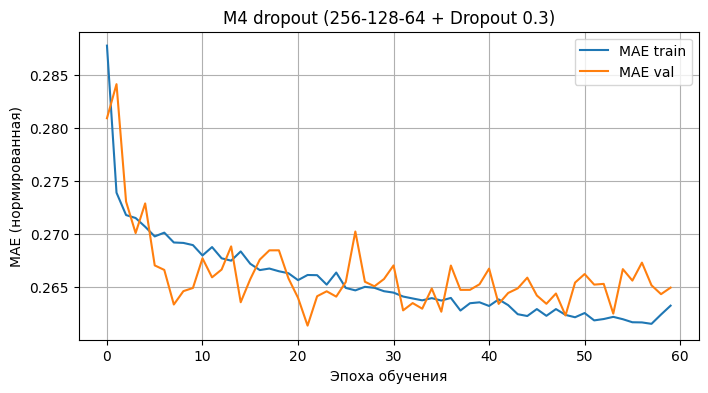

In [ ]:
name4 = 'M4 dropout (256-128-64 + Dropout 0.3)'
print('=== ' + name4 + ' ===')

m4 = Sequential([
    Dense(256, activation='relu', input_dim=x_train_01.shape[1]),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    Dropout(0.3),
    Dense(1,   activation='linear'),
])
m4.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])

rub4 = []
h4 = m4.fit(x_tr, y_tr,
            validation_data=(x_val, y_val),
            epochs=60, batch_size=128, verbose=0,
            callbacks=[make_rub_callback(m4, x_val, y_val_orig, rub4)])

mae4, _ = eval_net_scaled(m4, x_val, y_val_orig)
print(f'\nИтоговый MAE (тыс. руб.): {mae4:.2f}')
plot_history(h4, name4)

results.append({'name': name4,
                'params': 'Dense 256-128-64, Dropout 0.3, Adam 1e-3, bs=128, ep=60',
                'mae': mae4, 'history': h4, 'rub_history': rub4})


### Модель 5 — Functional API + tanh + Adagrad
**Гиперпараметры:** Functional API; 3 слоя (200 `tanh` → 100 `relu` → 50 `relu`), оптимизатор `Adagrad(lr=1e-2)`, `batch_size=64`, 40 эпох.
Идея: проверить вариант с другой активацией и оптимизатором — `tanh` ограничивает выход скрытых нейронов, `Adagrad` хорошо работает с разреженными признаками (а у нас как раз one-hot/multi-hot).

=== M5 Functional+tanh (Adagrad 1e-2) ===
  Эпоха   1 | MAE val (тыс. руб.) =  31.86
  Эпоха  10 | MAE val (тыс. руб.) =  31.62
  Эпоха  20 | MAE val (тыс. руб.) =  31.59
  Эпоха  30 | MAE val (тыс. руб.) =  31.55
  Эпоха  40 | MAE val (тыс. руб.) =  31.54

Итоговый MAE (тыс. руб.): 31.54


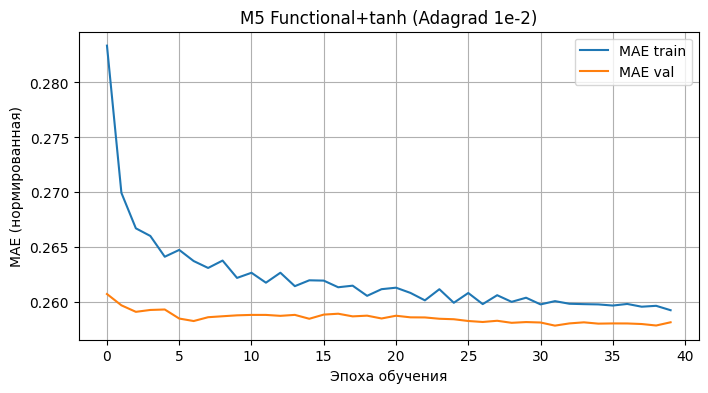

In [ ]:
name5 = 'M5 Functional+tanh (Adagrad 1e-2)'
print('=== ' + name5 + ' ===')

inp = Input(shape=(x_train_01.shape[1],))
x = Dense(200, activation='tanh')(inp)
x = Dense(100, activation='relu')(x)
x = Dense(50,  activation='relu')(x)
out = Dense(1, activation='linear')(x)
m5 = Model(inp, out)
m5.compile(optimizer=Adagrad(learning_rate=1e-2), loss='mse', metrics=['mae'])

rub5 = []
h5 = m5.fit(x_tr, y_tr,
            validation_data=(x_val, y_val),
            epochs=40, batch_size=64, verbose=0,
            callbacks=[make_rub_callback(m5, x_val, y_val_orig, rub5)])

mae5, _ = eval_net_scaled(m5, x_val, y_val_orig)
print(f'\nИтоговый MAE (тыс. руб.): {mae5:.2f}')
plot_history(h5, name5)

results.append({'name': name5,
                'params': 'Functional 200(tanh)-100-50, Adagrad 1e-2, bs=64, ep=40',
                'mae': mae5, 'history': h5, 'rub_history': rub5})


### Модель 6 — пирамидальная глубокая (BN + Dropout, RMSprop)
**Гиперпараметры:** 5 скрытых слоёв (512→256→128→64→32) с `BatchNormalization` и `Dropout(0.2)` между ними, оптимизатор `RMSprop(lr=5e-4)`, `batch_size=256`, 80 эпох.
Идея: «всё и сразу» — глубина + BN + Dropout + другой оптимизатор. Самая ёмкая модель в сравнении.

=== M6 deep pyramid (BN+Dropout, RMSprop 5e-4) ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Эпоха   1 | MAE val (тыс. руб.) =  37.58
  Эпоха  10 | MAE val (тыс. руб.) =  30.95
  Эпоха  20 | MAE val (тыс. руб.) =  30.82
  Эпоха  30 | MAE val (тыс. руб.) =  30.82
  Эпоха  40 | MAE val (тыс. руб.) =  30.90
  Эпоха  50 | MAE val (тыс. руб.) =  30.82
  Эпоха  60 | MAE val (тыс. руб.) =  31.06
  Эпоха  70 | MAE val (тыс. руб.) =  30.88
  Эпоха  80 | MAE val (тыс. руб.) =  31.00

Итоговый MAE (тыс. руб.): 31.00


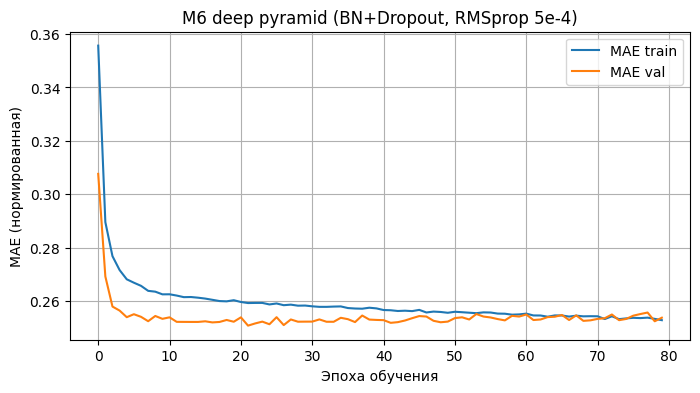

In [ ]:
name6 = 'M6 deep pyramid (BN+Dropout, RMSprop 5e-4)'
print('=== ' + name6 + ' ===')

m6 = Sequential([
    Dense(512, input_dim=x_train_01.shape[1]),
    BatchNormalization(), Activation('relu'), Dropout(0.2),

    Dense(256), BatchNormalization(), Activation('relu'), Dropout(0.2),
    Dense(128), BatchNormalization(), Activation('relu'), Dropout(0.2),
    Dense(64),  BatchNormalization(), Activation('relu'),
    Dense(32),  Activation('relu'),
    Dense(1,    activation='linear'),
])
m6.compile(optimizer=RMSprop(learning_rate=5e-4), loss='mse', metrics=['mae'])

rub6 = []
h6 = m6.fit(x_tr, y_tr,
            validation_data=(x_val, y_val),
            epochs=80, batch_size=256, verbose=0,
            callbacks=[make_rub_callback(m6, x_val, y_val_orig, rub6)])

mae6, _ = eval_net_scaled(m6, x_val, y_val_orig)
print(f'\nИтоговый MAE (тыс. руб.): {mae6:.2f}')
plot_history(h6, name6)

results.append({'name': name6,
                'params': '5 Dense пирамида + BN + Dropout 0.2, RMSprop 5e-4, bs=256, ep=80',
                'mae': mae6, 'history': h6, 'rub_history': rub6})


## 6. Сводный анализ результатов

In [ ]:
# Таблица результатов
summary = pd.DataFrame([
    {'Модель': r['name'],
     'Гиперпараметры': r['params'],
     'MAE val (тыс. руб.)': round(r['mae'], 2)}
    for r in results
])
summary = summary.sort_values('MAE val (тыс. руб.)').reset_index(drop=True)
summary


,Модель,Гиперпараметры,MAE val (тыс. руб.)
0,"M6 deep pyramid (BN+Dropout, RMSprop 5e-4)","5 Dense пирамида + BN + Dropout 0.2, RMSprop 5...",31.00
1,"M3 wide (1024-64, Adam 5e-4)","Dense 1024-64, Adam 5e-4, bs=512, ep=40",31.03
2,M5 Functional+tanh (Adagrad 1e-2),"Functional 200(tanh)-100-50, Adagrad 1e-2, bs=...",31.54
3,"M1 baseline (Dense 64-32, Adam 1e-3)","2×Dense (64,32), Adam 1e-3, bs=128, ep=30",31.62
4,M4 dropout (256-128-64 + Dropout 0.3),"Dense 256-128-64, Dropout 0.3, Adam 1e-3, bs=1...",32.37
5,"M2 deep+BN (256-128-64-32, Adam 1e-3)","BN + 4 Dense (256,128,64,32), Adam 1e-3, bs=25...",32.49


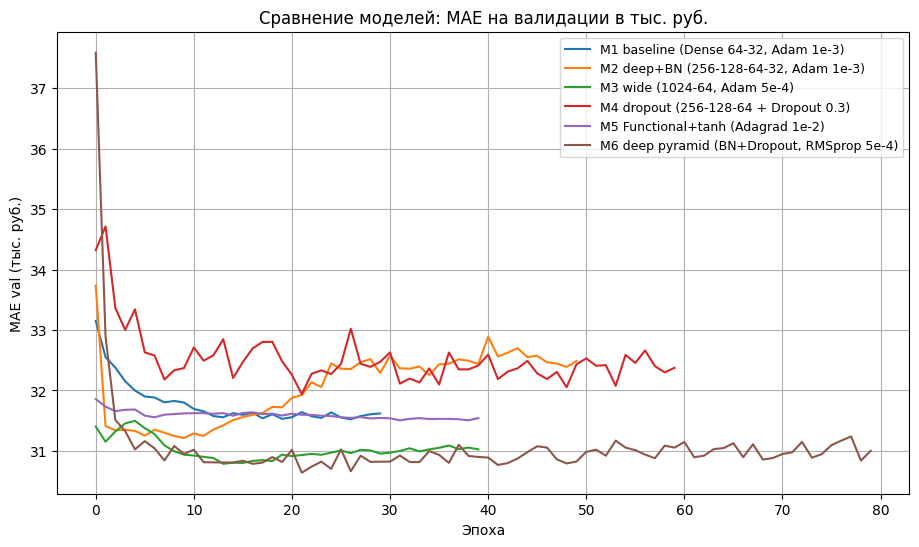

In [ ]:
# График сравнения MAE (в тыс. руб.) по эпохам — все 6 моделей
plt.figure(figsize=(11, 6))
for r in results:
    plt.plot(r['rub_history'], label=r['name'])
plt.xlabel('Эпоха')
plt.ylabel('MAE val (тыс. руб.)')
plt.title('Сравнение моделей: MAE на валидации в тыс. руб.')
plt.legend(loc='upper right', fontsize=9)
plt.grid(); plt.show()


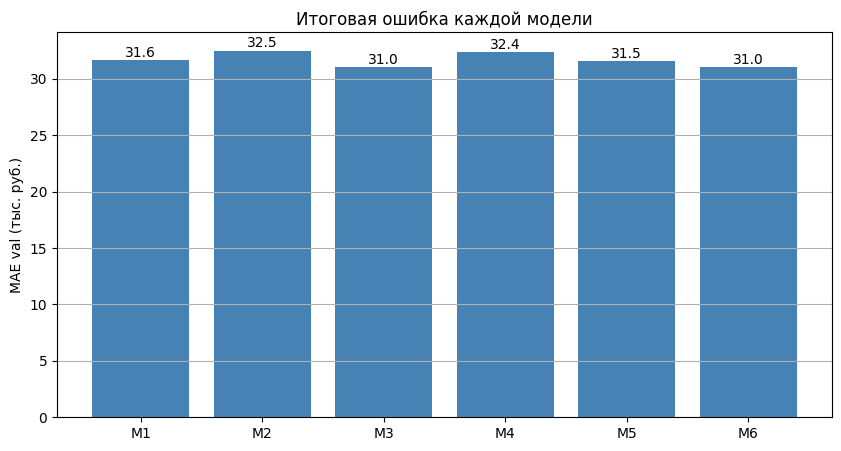

In [ ]:
# Бар-чарт итоговых ошибок
plt.figure(figsize=(10, 5))
plt.bar(range(len(results)),
        [r['mae'] for r in results],
        color='steelblue')
plt.xticks(range(len(results)),
           [f'M{i+1}' for i in range(len(results))])
plt.ylabel('MAE val (тыс. руб.)')
plt.title('Итоговая ошибка каждой модели')
for i, r in enumerate(results):
    plt.text(i, r['mae'] + 0.3, f"{r['mae']:.1f}",
             ha='center', fontsize=10)
plt.grid(axis='y'); plt.show()
